## Hugging Face: BERT

In [8]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import pandas as pd
from tqdm import tqdm

In [9]:
all_data_df = pd.read_csv('all_data.csv')

In [12]:
# Prepare truncated version of the text column (if not already done)
def truncate_text(text, max_length=512):
    encoded = tokenizer.encode(
        str(text),
        max_length=max_length,
        truncation=True,
        add_special_tokens=True
    )
    return tokenizer.decode(encoded, skip_special_tokens=True)

all_data_df["truncated_text"] = all_data_df["text"].apply(truncate_text)

In [15]:
from transformers import pipeline
from tqdm import tqdm
from tqdm import TqdmMonitorWarning

classifier = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device=0)

texts = all_data_df["truncated_text"].astype(str).tolist()
batch_size = 32
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="Processing"):
    batch = texts[i:i+batch_size]
    batch_result = classifier(batch, truncation=True)
    results.extend(batch_result)

all_data_df["hf_sentiment"] = [r["score"] for r in results]

Device set to use cuda:0
Processing: 100%|██████████| 690/690 [03:56<00:00,  2.91it/s]


In [16]:

all_data_df["hf_sentiment"] = [r["label"] for r in results]

In [20]:
all_data_df["rating_x"] = pd.to_numeric(all_data_df["rating_x"], errors='coerce')

all_data_df["hf_sentiment"] = all_data_df["hf_sentiment"].astype(str).str.extract(r"(\d)").astype(float)

all_data_df = all_data_df.dropna(subset=["text"])

mismatches = all_data_df[all_data_df["rating_x"] != all_data_df["hf_sentiment"]]


print(f"Not matching cases: {len(mismatches)} из {len(all_data_df)} ({len(mismatches)/len(all_data_df)*100:.2f}%)")


mismatches[["text", "rating_x", "hf_sentiment"]].sample(15)

Not matching cases: 4766 из 21098 (22.59%)


,text,rating_x,hf_sentiment
3044,"I had booked a park and ride for the airport, ...",1.0,2.0
16098,Nice secure place to park with frequent shuttl...,5.0,4.0
12160,"Courteous staff, simple in and out process, ti...",5.0,4.0
2833,"Brock is really on point, he follows my reques...",5.0,4.0
17317,"i was unable to select seats, my wife and 5 yr...",2.0,1.0
18370,easy access from Greyhound/Hayward Bart statio...,5.0,4.0
12390,"Parking was as expected, bus frequency was ver...",5.0,4.0
2495,"I tried to make my reservation online, found a...",4.0,2.0
154,Trip was nice and informative. Trolley rob did...,5.0,4.0
20160,managed to get a complicated itinerary at a ve...,5.0,4.0


## BERT with weights (less correlation with rating)

In [22]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
from tqdm import tqdm
import pandas as pd

model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
batch_size = 32

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

texts = all_data_df["text"].dropna().astype(str).tolist()

def get_sentiment_scores(texts, batch_size=32):
    results = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Predicting"):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            probs = F.softmax(outputs.logits, dim=1)  # (batch_size, 5)

        weighted_avg = (probs * torch.arange(1, 6, device=device)).sum(dim=1)
        results.extend(weighted_avg.cpu().tolist())

    return results

sentiment_scores = get_sentiment_scores(texts, batch_size=batch_size)

all_data_df = all_data_df.dropna(subset=["text"]).copy()
all_data_df["bert_weighted_score"] = sentiment_scores


Predicting: 100%|██████████| 660/660 [06:43<00:00,  1.64it/s]


<ipython-input-23-1328175924>:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped_scores, labels=ratings)


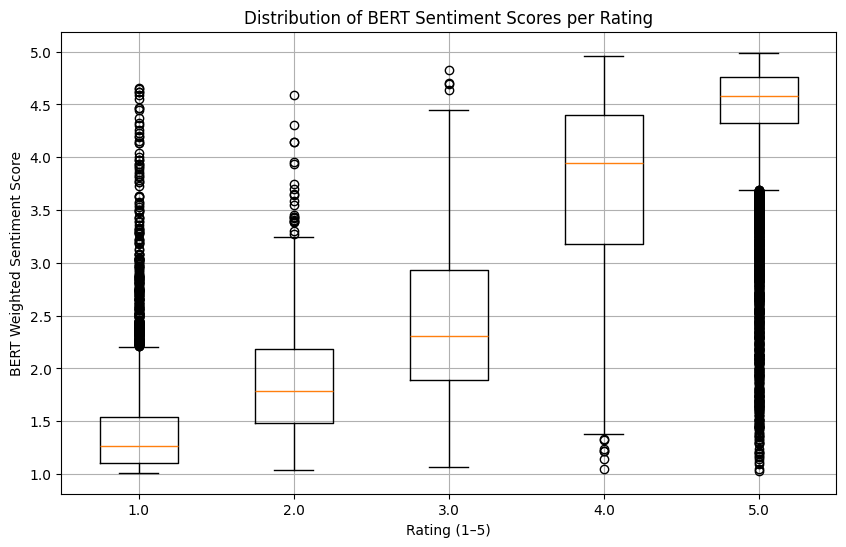

In [23]:
import matplotlib.pyplot as plt

ratings = sorted(all_data_df["rating_x"].dropna().unique())
grouped_scores = [all_data_df[all_data_df["rating_x"] == r]["bert_weighted_score"].dropna() for r in ratings]

plt.figure(figsize=(10, 6))
plt.boxplot(grouped_scores, labels=ratings)
plt.title("Distribution of BERT Sentiment Scores per Rating")
plt.xlabel("Rating (1–5)")
plt.ylabel("BERT Weighted Sentiment Score")
plt.grid(True)
plt.show()


In [26]:
all_data_df["rating_x"] = pd.to_numeric(all_data_df["rating_x"], errors='coerce')

all_data_df["bert_weighted_score"] = all_data_df["bert_weighted_score"].round()

mismatches = all_data_df[all_data_df["rating_x"] != all_data_df["bert_weighted_score"]]


print(f"Not matching cases: {len(mismatches)} out of {len(all_data_df)} ({len(mismatches)/len(all_data_df)*100:.2f}%)")

mismatches[["text", "rating_x", "bert_weighted_score"]].sample(15, random_state=42)


Not matching cases: 8118 out of 21098 (38.48%)


,text,rating_x,bert_weighted_score
16834,The agent was really helpful!Got all my doubts...,4.0,5.0
8937,I love trusted Housesitters and have used them...,5.0,4.0
3937,"It was easy and quick to make a booking,import...",5.0,4.0
19970,"Got me a good deal for my preferred dates , Ch...",5.0,4.0
5730,Search and booking was simple,5.0,4.0
3221,"First of all, reservation was straightforward ...",5.0,2.0
5953,"Website is easy to use, quick, and provides se...",5.0,4.0
15143,Veer nice app,5.0,4.0
3148,Tom was very knowledgeable and helpful.,5.0,4.0
20336,Rue was proactive on tracking my flight change...,5.0,4.0


In [27]:
all_data_df

,name,country,rating_x,title,text,date_of_experience,has_reply,company_x,company_y,website,...,number_review,domain,5_star_percentage,4_star_percentage,3_star_percentage,2_star_percentage,1_star_percentage,truncated_text,hf_sentiment,bert_weighted_score
0,Przemysław Rosuł,PL,1.0,Ignoring the specified pickup time,Ignoring the specified pickup time. Providing ...,2025-05-13,0.0,www.viator.com,Viator.com,www.viator.com,...,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,ignoring the specified pickup time. providing ...,1.0,1.0
1,kathy mrozek,US,5.0,Athens Evening food tour with Katrina,"Katrina, the tour guide was fabulous! She mad...",2025-05-15,0.0,www.viator.com,Viator.com,www.viator.com,...,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,"katrina, the tour guide was fabulous! she made...",5.0,5.0
2,MARY MURRAY,US,5.0,All you need for travel with confidence,A great app! My excursions have been awesome! ...,2025-05-12,0.0,www.viator.com,Viator.com,www.viator.com,...,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,a great app! my excursions have been awesome! ...,5.0,5.0
3,K Shay Smith,MX,1.0,I booked the excursion and paid the…,I booked the excursion and paid the money up f...,2025-05-12,0.0,www.viator.com,Viator.com,www.viator.com,...,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,i booked the excursion and paid the money up f...,1.0,3.0
4,Jeff Paine,US,5.0,Great food tour of Prague. Great conversation ...,Great food tour of Prague,2025-05-07,0.0,www.viator.com,Viator.com,www.viator.com,...,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,great food tour of prague,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21110,Asma,US,1.0,I rented a car with Expedia and paid…,I rented a car with Expedia and paid the money...,2025-02-08,0.0,www.expedia.com,Expedia,www.expedia.com,...,10149.0,"['Travel Aggregator', 'Travel Agency']",4%,<1%,<1%,2%,92%,i rented a car with expedia and paid the money...,1.0,1.0
21111,Algirdas Dembinskas,US,1.0,Platinum user review,I’ve been using Expedia frequently for over 10...,2025-02-16,0.0,www.expedia.com,Expedia,www.expedia.com,...,10149.0,"['Travel Aggregator', 'Travel Agency']",4%,<1%,<1%,2%,92%,i ve been using expedia frequently for over 10...,2.0,2.0
21112,Erin McLaughlin,US,1.0,NEVER book a flight through Expedia,NEVER book a flight through Expedia. “Fully re...,2025-02-15,0.0,www.expedia.com,Expedia,www.expedia.com,...,10149.0,"['Travel Aggregator', 'Travel Agency']",4%,<1%,<1%,2%,92%,never book a flight through expedia. fully ref...,1.0,1.0
21113,Lane Rosen,US,1.0,Expedia a Very deceptive company,Very deceptive company. Charge double the reg...,2025-02-14,0.0,www.expedia.com,Expedia,www.expedia.com,...,10149.0,"['Travel Aggregator', 'Travel Agency']",4%,<1%,<1%,2%,92%,very deceptive company. charge double the regu...,1.0,1.0


In [29]:
all_data_df.to_csv('reviews_data.csv', index=False)